---
title: "Simple iterations"
subtitle: "Lecture 4: Chapter 2: Solving nonlinear equations in 1d"
code-fold: true
format:
  html: default
  pdf: default
---

{{< include ../extras/_lecture-header.html >}}

::: {.callout-warning}

Notes for this lecture have not been updated since we met (stay tuned for updates)

:::

::: {.callout-note}

This lecture is based on Chapter 1 of [Fundamentals of Numerical Computation by Driscoll, Braun] which is avaliable <a href="https://fncbook.com/overview/" 
     class="btn btn-outline-info btn-sm" 
     target="_blank" 
     rel="noopener noreferrer">
    <i class="bi bi-archive me-1" aria-hidden="true"></i>
    online
    <span class="visually-hidden">(opens in a new tab)</span>
  </a>

:::

## Recap 

Last time: conditioning, stability; 

Start of Chapter 2: roots (zeros), intermediate value theorem and change of sign theorem, example $f(x) = e^x - 2x - 1$ on $[1,2]$, fixed points, Brouwer's fixed point theorem.

- ChimeIn

In [1]:
#| include: false

# IF YOU HAVE DOWNLOADED THESE NOTES, 
# LET ME KNOW AND I'LL GIVE OUT 
# CHOCOLATE IN THE NEXT LECTURE

using Polynomials, Plots, LaTeXStrings

::: {.box}

@exr-change-sign-2

:::

::: {.callout-tip collapse=true}
# Hints

Since $f$ is continuous and we have $f(1) = e - 3 < 0 < e^2 - 5 = f(2)$ and so we can apply change of sign theorem to $f$ on the interval $[1,2]$: there exists $\xi \in [1,2]$ with $f(\xi) = 0$. 

Here's a picture:

(f(1), f(2)) = (-0.2817181715409549, 2.3890560989306504)


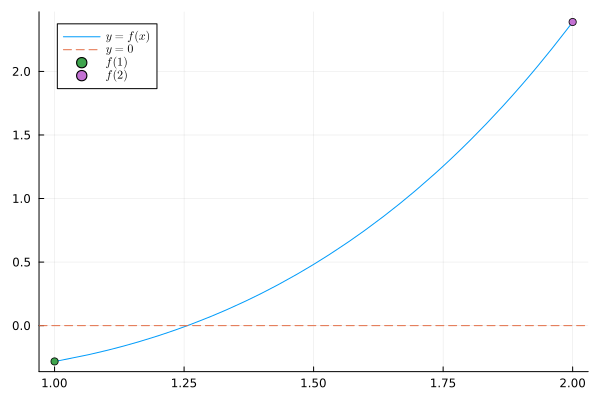

In [2]:
f(x) = exp(x) - 2*x - 1
g(x) = log( 2*x + 1 )    
h(x) = (exp(x) - 1)/2
id(x) = x

@show (f(1), f(2))
plot( f, 1, 2, label=L"y = f(x)" )
hline!([0], label=L"y = 0", linestyle=:dash)
scatter!([1 2], [f(1) f(2)] , label=[L"f(1)" L"f(2)"]) 

Rearranging $f(x) = 0$ gives $g(x) = x$ and $h(x) = x$. 

Since $g$ is increasing we have $1 < \log3 = g(1) \leq g(x) \leq g(2) = \log5 < 2$ for all $x \in [1,2]$. We can therefore apply Brouwer's fixed point theorem to conclude there exists $\xi \in [1,2]$ such that $g(\xi) = \xi$. 

On the other hand $h(1) = \frac{e-1}{2} < 1$ (and $g(2) > 2$) and so $h$ does not map $[1,2]$ onto $[1,2]$ and we cannot apply Brouwer's fixed point theorem to $h$. 

Here's a picture:

(g(1), g(2)) = (1.0986122886681098, 1.6094379124341003)
(h(1), h(2)) = (0.8591409142295225, 3.194528049465325)


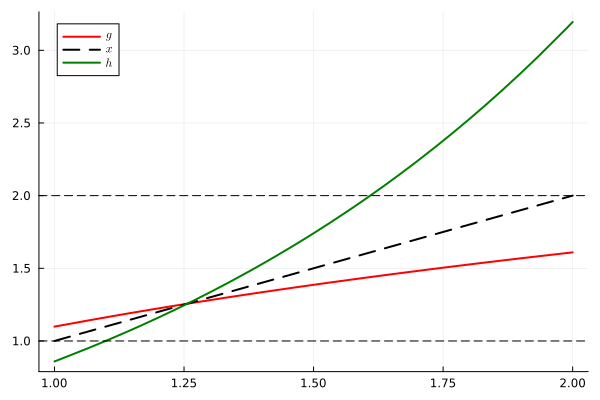

In [3]:
@show (g(1), g(2));
@show (h(1), h(2));

plot( [g, id, h], 1, 2, 
    label=[L"g" L"x" L"h"], lw=2,
    color=["red" "black" "green"], linestyle=[:solid :dash :solid] )
hline!( [1,2], linestyle=:dash, primary=false, color="black" )

:::

## Simple iterations

Suppose we want to find fixed points of a continuous function $g:[a,b] \to [a,b]$. The **simple iteration** is defined by

$$
\begin{align}
    x_1 &\in [a,b] \nonumber\\
    %
    x_{n+1} &:= g(x_n).
\end{align}
$$ {#eq-simple-iteration}

We implement this here:

In [4]:
function simple_iteration(g, x1; N=100, tol=1e-10, flag=false)
    x = Vector{Float64}(undef, N)
    x[1] = x1
    
    for n ∈ 2:N
        x[n] = g(x[n-1])
        
        if !isfinite(x[n])
            return x[1:n], false 
        end

        # compute relative error
        rel_err = abs(x[n] - x[n-1]) / max(abs(x[n]), 1e-12)
        
        if rel_err < tol
            return x[1:n], true 
        end
    end
    
    if flag
        @warn "Fixed-point iteration did not converge within $N iterations."
    end
    return x, false
end

simple_iteration (generic function with 1 method)

::: {#lem-simple-1}

Suppose that $(x_{n}) \to \xi$ then $\xi$ is a fixed point of $g$.

::: 

::: {.proof} 

Since $(x_{n+1}) \to \xi$, we have $\xi = \lim_{n\to \infty} g(x_n) = g(\xi)$ by continuity of $g$.

:::

::: {#exm-change-sign-3}

Returning to @exr-change-sign-1 and @exr-change-sign-2 where $f(x) = e^x - 2x - 1$. Recall that finding roots of $f$ in $[1,2]$ is equivalent to finding fixed points of $g$ and $h$ as defined in @eq-L3-g-h. 

Let's see if the iterative methods $x_{n+1} = g(x_n)$ and $y_{n+1} = h(y_n)$ converge for $x_1 = y_1 = 1$: 

:::


(x[end], y[end]) = (1.2564242398858796, 1.374528751196813e-5)


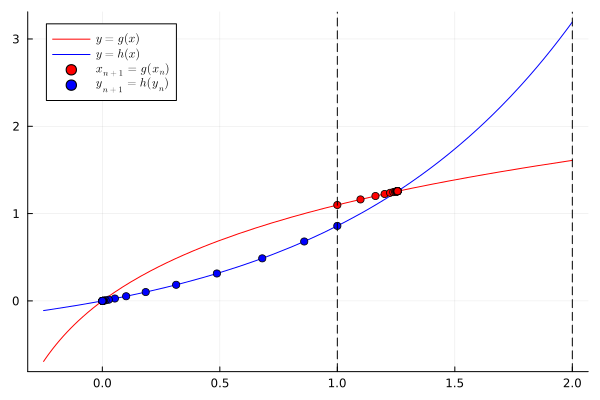

In [23]:
x, _ = simple_iteration( g, 1; N=20 )
y, _ = simple_iteration( h, 1; N=20 );
@show (x[end], y[end]);

plot( [g, h] , -0.25, 2; 
    label=[ L"y = g(x)" L"y = h(x)"], color=[:red :blue])
scatter!( x, g.(x); 
    label=L"x_{n+1} = g(x_n)", color=:red)
scatter!( y, h.(y); 
    label=L"y_{n+1} = h(y_n)", color=:blue)
vline!( [1, 2]; 
    linestyle=:dash, color=:black, primary=false)

Here, we see that $x_n \to \xi \approx 1.255 \in [1,2]$ but $y_{n} \to \widetilde{\xi} \approx 0$ so the formulations $g(x) = x$ and $h(x) = x$ are equivalent, but they lead to different numerical methods.

Animations:

In [6]:
# code-fold: true

function animate_simple( g, x1; N=10, label="g") 

    x, _ = simple_iteration( g, x1; N=20 )

    plot( [id, g] , min(-0.25,x[1]-1e-3), max(2,x[1]+1e-3), 
    label=[ L"x" L"%$label"], title=L"\textrm{simple~iteration~} x_1 = %$x1 \textrm{~and~} x_{n+1} = %$label(x_{n})",
    color=["black" "red"], linestyle=[:dash :solid])

    anim = @animate for n ∈ 2:2(length(x)-1)
        if (n%2 == 0)
            k = Int(n/2)
            plot!( [x[k], x[k]], [x[k], x[k+1]], 
                primary=false, color=:black, lw=2)
        else
            k = Int((n+1)/2)
            plot!( [x[k-1], x[k]], [x[k],x[k]], 
                primary=false, color=:black, lw=2)
        end
    end
    return anim 
end

animate_simple (generic function with 1 method)

[ Info: Saved animation to c:\Users\jack6\Math5485-Fall-2026\Math5485\images\stable.gif


Plots.AnimatedGif("c:\\Users\\jack6\\Math5485-Fall-2026\\Math5485\\images\\stable.gif")
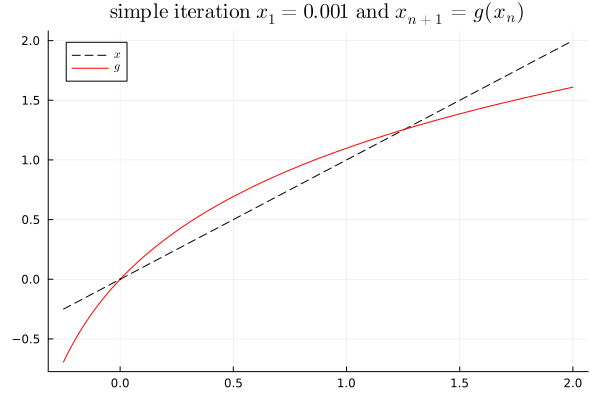

In [26]:
anim = animate_simple( g, 1e-3; N=20, label="g")
gif(anim, "../images/stable.gif", fps = 3)

[ Info: Saved animation to c:\Users\jack6\Math5485-Fall-2026\Math5485\images\unstable.gif


Plots.AnimatedGif("c:\\Users\\jack6\\Math5485-Fall-2026\\Math5485\\images\\unstable.gif")
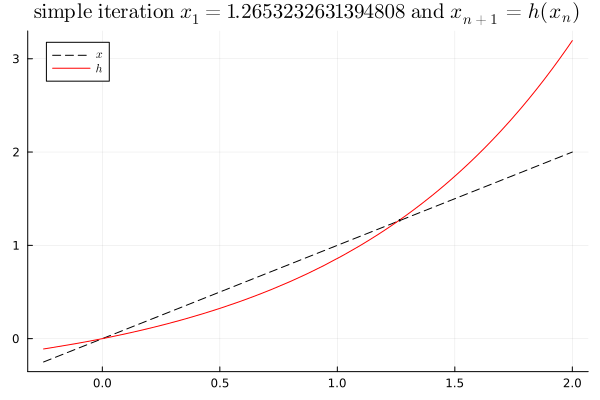

In [8]:
anim = animate_simple( h, x[end]+1e-2; N=10, label="h")
gif(anim, "../images/unstable.gif", fps = 3)

In fact, $(\xi, \tilde{\xi})$ approximate the two real roots of $f$:

(f(1), f(2)) = (-0.2817181715409549, 2.3890560989306504)


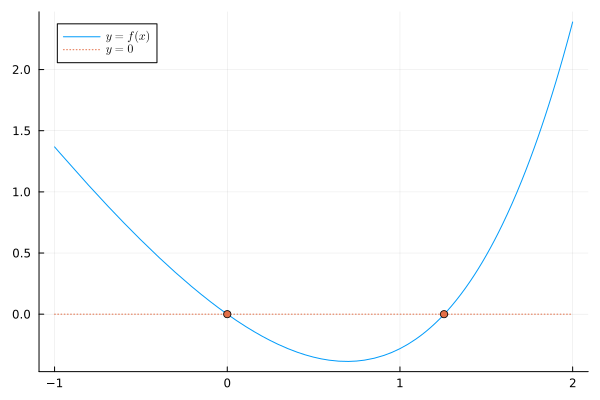

In [9]:
@show ( f(1), f(2) )

plot( f, -1, 2; label = L"y = f(x)" )
plot!( x->0; label = L"y = 0", linestyle=:dot )
scatter!( [x[end], y[end]], [0, 0]; primary=false )

::: {#def-order-of-convergences}
# Order of convergence

Let $x_n \to \xi$. Suppose that there exist $\alpha\geq1$ and $\mu \geq 0$ such that

\begin{align}
    \lim_{n\to\infty}  \frac{\left|x_{n+1} - \xi\right|}{\left|x_n - \xi\right|^\alpha} = \mu
\end{align}

* If $\alpha = 1$ and $\mu \in (0,1)$, we say the convergence is *linear*,
* If $\alpha = 1$ but $\mu = 0$, we say the convergence is *superlinear* (i.e. faster than linear),
* If $\alpha = 1$ and $\mu = 1$, we say the convergence is *sublinear* (i.e slower than linear),
* If $\alpha = 2$, we say the convergence is *quadratic*,...

In the case where *(i)* $\alpha = 1, \mu \in (0,1)$ or *(ii)* $\alpha>1, \mu> 0$, we say

* $x_n \to \xi$ with *order* $\alpha$, 
* $\mu$ is the *asymptotic error constant*, and
* $\rho := - \log_{10} \mu$ is the *asymptotic rate of convergence*.

:::

* Define the errors $e_n := |x_{n}-\xi|$. Then, we have $e_{n+1} \approx \mu e_{n}^\alpha$,
* For linear convergence, $e_{N+1} \approx \mu e_N = 10^{-\rho} e_N$ and so $\rho$ measures the number of decimal digits of accuracy gained in one iteration (for sufficiently large $N$).

::: {#exm-change-sign-4}

Let's go back to our example: $f(x) = e^x - 2x - 1$. We have defined $g(x) = \log( 2x + 1 )$ and we are trying to solve the fixed point problem $g(x) = x$. 

(This is mathematically equivalent to $f(x) = 0$.)

We have seen (numerically) that $x_{n+1} = g(x_n)$ with $x_1$ converges to $\xi = g(\xi) \approx 1.26$. What is the order of convergence? What is the asymptotic error constant? Asymptotic rate of convergence?

:::

(It turns out that $\xi = g(\xi) \approx 1.256$ can be written in terms of the LambertW function.)

In [10]:
using LambertW 
ξ = -( 1/2 + lambertw(-(1/2) * exp(-1/2), -1) )
println("ξ = $ξ")

ξ = 1.2564312086261695


In [24]:
μₙ = @. abs( ( x[2:end] - ξ )/(x[1:end-1] - ξ ) )

19-element Vector{Float64}:
 0.6154434977067526
 0.5965577179668249
 0.5851632047756364
 0.5784563522754123
 0.5745645700825062
 0.5723246633711306
 0.5710414920687147
 0.5703083577906018
 0.5698901195281622
 0.569651729099643
 0.569515916456726
 0.5694385647462568
 0.5693945163234355
 0.569369434946979
 0.569355154232495
 0.5693470233879584
 0.5693423940983908
 0.5693397584481151
 0.5693382578603982

In [18]:
μ, ρ = μₙ[end], -log10( μₙ[end] )
println("μ = $μ")
println("ρ = $ρ")

μ = 0.5693382578603982
ρ = 0.2446296318929979


Since ``μₙ``  appears to converge to $\mu \in (0,1)$, we have $x_n \to \xi$ linearly with asymptotic error constant $\mu\approx 0.569$ and asymptotic rate of convergence $\rho \approx 0.245$. 

We will prove that $x_{n+1} = g(x_n)$ converges linearly and show that $\mu = |g'(\xi)|$. Our computed value of $\mu$ (after $20$ iterations) is close to this theoretical value: 

In [12]:
g′ = x -> 2/( 2*x + 1);
@show g′( ξ );

g′(ξ) = 0.569336274081677


::: {#def-contraction}

We say $g : [a,b] \to \mathbb R$ is a *contraction* if there exists an $L \in [0,1)$ such that $|g(x) - g(y)| \leq L|x-y|$ for all $x\in[a,b]$.

:::

::: {#exr-contraction-1}

[](../exercises/bank.html#bank-exr-contraction-1)

Suppose $g :[a,b] \to \mathbb R$ is continuously differentiable with $|g'(x)| \leq L < 1$ for all $x \in [a,b]$. Show that $g$ is a contraction with constant $L$.

::: {.exercise-hint style="display: none;"}

Use Taylor/mean value theorem: for $x, y \in [a,b]$ there exists $c \in [a,b]$ such that $g(x) - g(y) = g'(c) (x - y)$. 

:::

:::

::: {#thm-banach}
# Contraction Mapping Theorem (Banach fixed point theorem) 

Suppose $g:[a,b] \to[a,b]$ is a contraction. Then, there exists a unique fixed point $\xi = g(\xi) \in [a,b]$. Moreover, the iteration $x_{n+1} = g(x_n)$ converges to $\xi$ for all $x_1 \in [a,b]$

:::

**Proof.** By Brouwer's fixed point theorem ($g:[a,b] \to [a,b]$ is continuous), there exists a fixed point $\xi \in [a,b]$. If $\zeta$ is another fixed point, then there exists $L \in (0,1)$ such that

\begin{align}
    |\xi - \zeta| &= |g(\xi) - g(\zeta)| 
    \nonumber\\ 
    %
    &\leq L |\xi - \zeta| 
\end{align}

Here, we used the fact that $\xi, \zeta$ are fixed points of $g$ and that $g$ is a contraction. That is, $0 \leq (1-L) |\xi - \zeta| \leq 0$ and so $\xi = \zeta$. i.e. $\xi$ is unique.

Defining $x_{n+1} = g(x_n)$ for $x_1 \in [a,b]$, we have 

\begin{align}
    |x_{n+1} - \xi| &= |g(x_n) - g(\xi)| \nonumber\\
    %
    &\leq L |x_{n} - \xi| \nonumber\\
    %
    &\leq L^n |x_1 - \xi|.
\end{align}

Since $L \in (0,1)$, we have $L^n \to 0$ as $n \to \infty$ and thus $(x_n) \to \xi$.

::: {#exr-contraction-2}

[](../exercises/bank.html#bank-exr-contraction-2)

Take the simple iteration $x_{n+1} = g(x_n)$ for some contraction $g : [a,b] \to [a,b]$. Show that $(x_n)$ converges to the fixed point of $g$ in $[a,b]$ at least linearly with asymptotic error constant $\mu = |g'(\xi)|$.


::: {.exercise-hint style="display: none;"}

Notice that, by the mean value theorem, there exists $\eta_n$ between $x_{n}$ and $\xi$ for which  

\begin{align}
    \frac
        {|x_{n+1} - \xi|}
        {|x_n - \xi|}
    %
    &= \frac
        {|g(x_n) - g(\xi)|}
        {|x_n - \xi|} \nonumber\\
    %
    &= \frac
        {|g'(\eta_n)| |x_n - \xi|}
        {|x_n - \xi|} \nonumber\\
    %
    &= |g'(\eta_n)| \nonumber
\end{align}

Therefore, since $(x_n) \to \xi$, and $\eta_n$ is between $x_n$ and $\xi$, we have 

\begin{align}
    \lim_{n\to\infty}
    \frac
        {|x_{n+1} - \xi|}
        {|x_n - \xi|}
    %
    &= |g'(\xi)| \nonumber
\end{align}

and the order of convergence is at least linear with asymptotic error constant $\mu = |g'(\xi)|$.  

(Recal that, if $\mu = 0$, the order of convergence is superlinear)

:::
:::

::: {#exr-change-sign-5}

[](../exercises/bank.html#bank-exr-change-sign-5)

Show that $g(x) = \log( 2x + 1)$ is a contraction on $[1,2]$ with $L = \frac23$. Hence conclude that $x_{n+1} := g(x_n)$ converges for all $x_1 \in [1,2]$.

::: {.exercise-solution style="display: none;"}

Notice that $g'(x) = \frac{2}{2x+1}$ which is positive and decreasing on $[1,2]$. We therefore have $\frac25 = g'(2) \leq g'(x) \leq g'(1) = \frac{2}{3}$ and so $g$ is a contraction with $L = \frac23$ by @exr-contraction-1. Applying the contraction mapping theorem shows that $(x_n)$ converges linearly to the fixed point $\xi \in [1,2]$ of $g$.  

:::

:::

:::{.callout-tip}
# TO-DO

* Test 1: Wednesday, 
* Exercises throughout the notes,
* (Sign-up to office hours if you like)

:::

## Extra exercises

::: {#exr-2025-A2}

[](../exercises/bank.html#bank-exr-2025-A2)

*Assignment 2, Fall 2025, [25 pts].* Fix $a, x_1 > 0$ and define the iteration $x_{n+1} = \frac{1}{2}\big( x_n + \frac{a}{x_n} \big)$.  

1. ✍ Show that $x_{n+1}$ has the same sign as $x_n$, 
2. ✍ Suppose that $(x_n) \to \xi$. What is the value of $\xi$? 
3. 💻 Let $x$ be as in question 2. Show numerically that $(x_n) \to \xi$ for a few different choices of $a$ and $x_1$,
4. 💻 This iteration can be seen as a way of approximating $\xi$. What is the correseponding order of convergence?
   
:::

::: {#exr-Lambert-W-2 title="Lambert W function"}

[](../exercises/bank.html#bank-exr-Lambert-W-2)

*Assignment 3, Fall 2025.* The *Lambert W function* (also called the *product-log function*) $W : [0,\infty) \to [0,\infty)$ satisfies $W(a) e^{W(a)} = a$. Define $\Omega := W(1)$. 

1. ✍ Show that $\Omega \in [0.56, 0.58]$. 
2. ✍ Show that $\Omega$ is a fixed point of $g$ and $h$ as defined by  

\begin{align}
    g(x) = e^{-x}, \qquad h(x) = \log \left|\frac{1}{x}\right|
\end{align}

3. 💻 Show numerically that $x_{n+1} = g(x_n)$ converges and $y_{n+1} = h(y_n)$ diverges for a few different choices of $x_1$ and $y_1$.
4. ✍ Show that $g:[\frac{1}{e}, 1]\to[\frac{1}{e},1]$ with $|g'| < 1$, 
5. ✍ Explain why this means that the iteration $x_{n+1} = g(x_n)$ converges for all $x_1 \in [\frac{1}{e}, 1]$,
6. ✍ Now fix $x_1 \in \mathbb R$. Show that the sequence $(x_n)$ is eventually contained in $[0,1]$ and that $g : [0,1] \to [\frac{1}{e}, 1]$. Explain why this means that $(x_n)$ converges for all $x_1 \in \mathbb R$,
7. ✍ What is the order of convergence of this method? 
8. 💻 Confirm this numerically. 
9. ✍ Show that $(y_n)$ doesn't converge to $\Omega$ for any choice of $y_1 \not= \Omega$.

:::

::: {#exr-simple-iteration title="Simple iteration"}

[](../exercises/bank.html#bank-exr-simple-iteration)

*Midterm, Fall 2025, Optional section, 30 pts.* Define $g(x) = 1 + \frac{1}{1 + x}$ and $I := [1,2]$.

1. **[3 points]** Show that $g(x) \in I$ for all $x \in I$.
2. **[3 points]** Which theorem guarantees the existence of a fixed point $\xi = g(\xi) \in I$.
3. **[3 points]** Compute the value of $\xi$.
4. **[3 points]** Show that $L := \max_{x \in I} |g'(x)| = \frac14$.
5. **[3 points]** Explain why this means the iteration $x_{n+1} = g(x_n)$ converges to $\xi$ for all $x_1 \in I$.
6. **[5 points]** What is the order of convergence? 
7. **[5 points]** What is the asymptotic error constant?
8. **[5 points]** Fix $x_1 \in I$. Find $n$ for which the error bound $|x_{n+1} - \xi| \leq \frac{1}{64}$ is guaranteed. 

:::